# Classificação de Dígitos Manuscritos com Redes Neurais MLP

## Objetivo
Construir uma rede neural MLP utilizando TensorFlow/Keras para classificar dígitos manuscritos de 0 a 9 usando o dataset MNIST.

Etapas:
- Carregamento e exploração dos dados;
- Normalização das imagens;
- Construção da MLP;
- Treinamento com backpropagation;
- Avaliação do modelo;
- Análise de erros e limitações.

In [1]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Treino:", x_train.shape)
print("Teste:", x_test.shape)

Treino: (60000, 28, 28)
Teste: (10000, 28, 28)


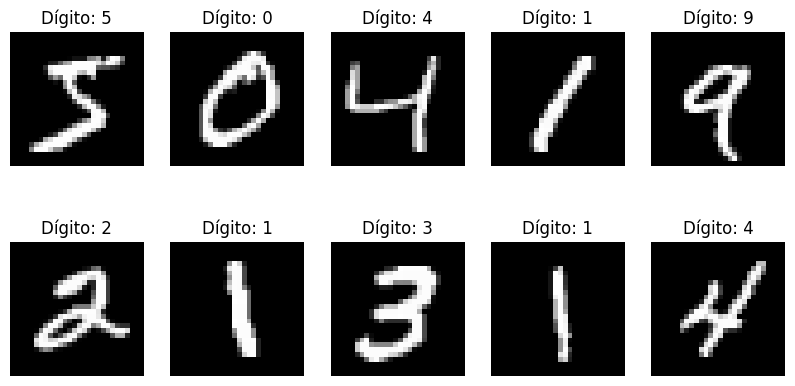

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Dígito: {y_train[i]}")
    plt.axis("off")

plt.show()

## Normalização

Os pixels variam de 0 a 255. A normalização transforma os valores para a faixa de 0 a 1.

In [4]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.min(), x_train.max())

0.0 1.0


## Construção da rede MLP

Arquitetura:

- Flatten: transforma a imagem 28x28 em vetor de 784 valores;
- Dense 128 neurônios com ReLU;
- Dropout para reduzir overfitting;
- Dense 64 neurônios com ReLU;
- Dense 10 neurônios com Softmax.

In [5]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.summary()

c:\Users\Administrator\Documents\PUC Minas\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8960 - loss: 0.3481 - val_accuracy: 0.9522 - val_loss: 0.1584
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9474 - loss: 0.1724 - val_accuracy: 0.9663 - val_loss: 0.1172
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9578 - loss: 0.1370 - val_accuracy: 0.9704 - val_loss: 0.0979
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9635 - loss: 0.1172 - val_accuracy: 0.9699 - val_loss: 0.0991
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9674 - loss: 0.1017 - val_accuracy: 0.9735 - val_loss: 0.0908
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9703 - loss: 0.0933 - val_accuracy: 0.9731 - val_loss: 0.0917
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9731 - loss: 0.0849 - val_accuracy: 0.9737 - val_loss: 0.0953
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9730 - loss: 0.0802 - 

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"Acurácia no teste: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9752 - loss: 0.0850
Acurácia no teste: 0.9752


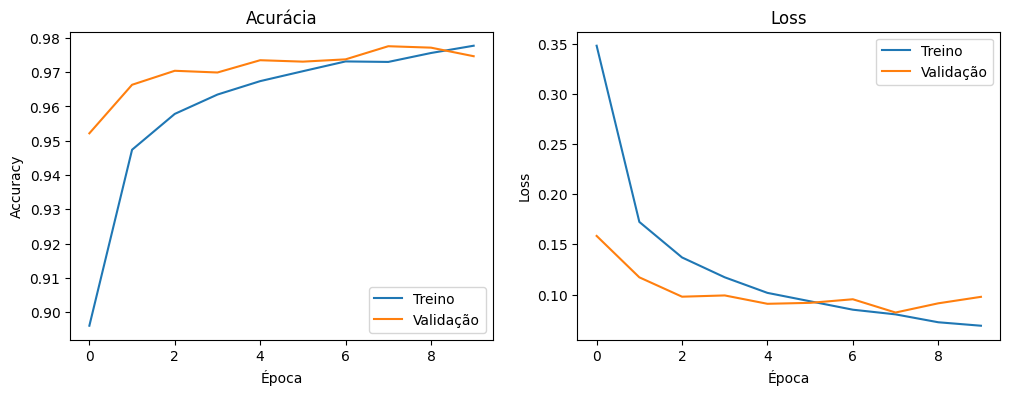

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Acurácia")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend(["Treino","Validação"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend(["Treino","Validação"])

plt.show()

In [10]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(y_test, predicted_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.95      0.99      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.97      0.97       892
           6       0.99      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.98      0.95      0.96       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.97      0.97     10000
weighted avg       0.98      0.98      0.98     10000



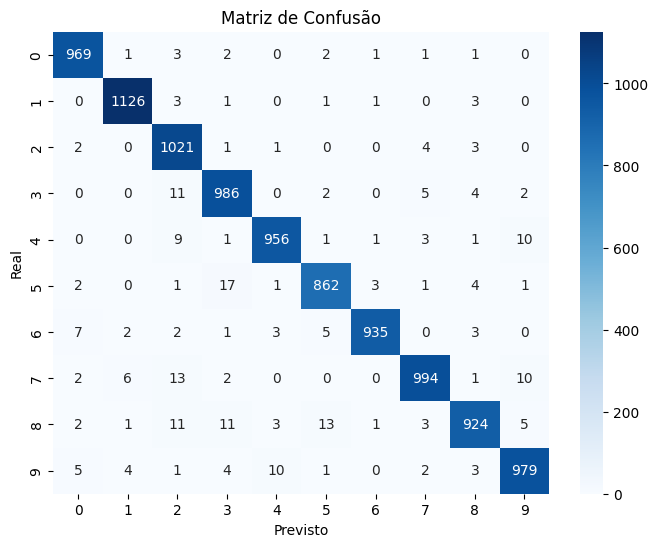

In [11]:
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")

plt.show()

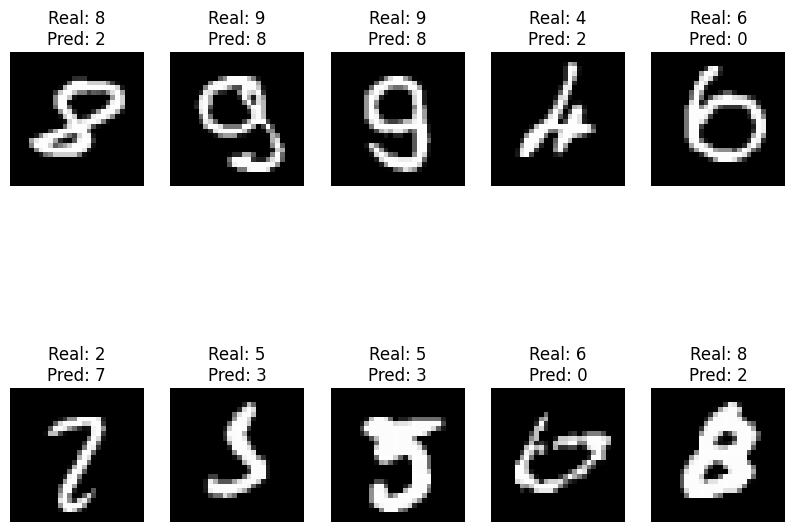

In [12]:
errors = np.where(predicted_classes != y_test)[0]

plt.figure(figsize=(10,8))

for i, idx in enumerate(errors[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(f"Real: {y_test[idx]}\nPred: {predicted_classes[idx]}")
    plt.axis("off")

plt.show()

# Conclusão

A MLP consegue classificar os dígitos MNIST com alta precisão.

Apesar do bom desempenho, ela possui limitações para imagens maiores porque não preserva relações espaciais entre pixels.

Redes Convolucionais (CNNs) são mais adequadas para visão computacional por aprenderem características locais como bordas e formas.